# Initializations

General imports and seed initializations.

In [8]:
import os
os.makedirs('out', exist_ok=True)

url = 'http://dihana.cps.unizar.es/~cadrete/asr/example1.zip'
if not os.path.exists('example1.zip'):
    os.system('wget ' + url)
if not os.path.exists('data'):
    os.system('unzip example1.zip')

In [9]:
import torch, random
import numpy as np  
import matplotlib.pyplot as plt
import matplotlib
def seed_everything(seed):      
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
seed_everything(42)

# Transformer Decoder

The transformer encoder is a stack of self-attention and feed-forward layers.
The transformer decoder for lm is a stack of causal self-attention, cross-attention and feed-forward layers.
The positional encoding is a learnable parameter and it is added to the input of the decoder.

In [10]:
class FeedForward(torch.nn.Module):
    def __init__(self, d_model=512, d_ff=1024, dropout=0.1, **kwargs):
        super().__init__()
        self.ff = torch.nn.Sequential(
            torch.nn.LayerNorm(d_model),
            torch.nn.Linear(d_model, d_ff),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(d_ff, d_model),
        )
        
    def forward(self, x):
        return self.ff(x)


class SelfAttention(torch.nn.Module):
    def __init__(self, d_model, n_heads=8, d_head=64, dropout=0.1, **kwargs):
        super().__init__()
        print('Self Attention, d_model:', d_model, 'n_heads:', n_heads, 'd_head:', d_head)
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_head
        self.scale = torch.sqrt(torch.tensor(d_head, dtype=torch.float32))
        self.norm = torch.nn.LayerNorm(d_model)
        self.q_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.v_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.k_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.dropout = torch.nn.Dropout(dropout)
        self.out = torch.nn.Linear(d_head*n_heads, d_model)

    def forward(self, x):
        x = self.norm(x)
        b = x.shape[0]
        q = self.q_linear(x).view(b, -1, self.n_heads, self.d_head)
        k = self.k_linear(x).view(b, -1, self.n_heads, self.d_head)
        v = self.v_linear(x).view(b, -1, self.n_heads, self.d_head) 
        scores = torch.einsum('bihd,bjhd->bhij', q, k) / self.scale     
        att = scores.softmax(dim=-1)
        att = self.dropout(att)
        out = torch.einsum('bhij,bjhd->bihd', att, v)
        out = self.dropout(out).reshape(b, -1, self.n_heads*self.d_head)
        out = self.out(out)
        return out

class Encoder(torch.nn.Module):
    def __init__(self, nb_layers=6, **kwargs):
        super().__init__()        
        self.seq_len = kwargs['seq_len']
        self.pos = torch.nn.Parameter(torch.randn(1, self.seq_len, kwargs['d_model']))
        self.att = torch.nn.ModuleList([SelfAttention(**kwargs) for _ in range(nb_layers)])
        self.ff = torch.nn.ModuleList([FeedForward(**kwargs) for _ in range(nb_layers)])
        
    def forward(self, x):
        b, t, d = x.shape
        x = x + self.pos[:, :t, :]
        for att, ff in zip(self.att, self.ff):
            x = x + att(x)
            x = x + ff(x)            
        return x


class CausalSelfAttention(torch.nn.Module):
    def __init__(self, d_model, n_heads=8, d_head=64, dropout=0.1, seq_len=1024,**kwargs):
        super().__init__()
        print('Causal Self Attention, d_model:', d_model, 'n_heads:', n_heads, 'd_head:', d_head, 'seq_len:', seq_len)
        self.seq_len = seq_len
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_head
        self.scale = torch.sqrt(torch.tensor(d_head, dtype=torch.float32))
        self.norm = torch.nn.LayerNorm(d_model)
        self.q_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.v_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.k_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.dropout = torch.nn.Dropout(dropout)
        self.out = torch.nn.Linear(d_head*n_heads, d_model)
        
        self.register_buffer("mask", torch.tril(torch.ones(self.seq_len, self.seq_len))[None, None, ...] == 0)
            
    def forward(self, x):
        x = self.norm(x)
        b, n, d = x.shape
        q = self.q_linear(x).reshape(b, -1, self.n_heads, self.d_head)
        k = self.k_linear(x).reshape(b, -1, self.n_heads, self.d_head)
        v = self.v_linear(x).reshape(b, -1, self.n_heads, self.d_head) 
        scores = torch.einsum('bihd,bjhd->bhij', q, k) / self.scale        
        scores = scores.masked_fill(self.mask[:,:,:n,:n], float('-inf'))
        att = scores.softmax(dim=-1)
        att = self.dropout(att)
        out = torch.einsum('bhij,bjhd->bihd', att, v)
        out = self.dropout(out).reshape(b, -1, self.n_heads*self.d_head)
        out = self.out(out)
        return out


class CrossAttention(torch.nn.Module):
    def __init__(self, d_model, n_heads=8, d_head=64, dropout=0.1, **kwargs):
        super().__init__()
        print('Cross Attention, d_model:', d_model, 'n_heads:', n_heads, 'd_head:', d_head)
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_head
        self.scale = torch.sqrt(torch.tensor(d_head, dtype=torch.float32))
        self.norm1 = torch.nn.LayerNorm(d_model)
        self.norm2 = torch.nn.LayerNorm(d_model)
        self.q_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.v_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.k_linear = torch.nn.Linear(d_model, d_head*n_heads)
        self.dropout = torch.nn.Dropout(dropout)
        self.out = torch.nn.Linear(d_head*n_heads, d_model)
    
    def forward(self, q, kv):
        q = self.norm1(q)
        kv = self.norm2(kv)  
        b = q.shape[0]
        q = self.q_linear(q).view(b, -1, self.n_heads, self.d_head)
        k = self.k_linear(kv).view(b, -1, self.n_heads, self.d_head)
        v = self.v_linear(kv).view(b, -1, self.n_heads, self.d_head) 
        scores = torch.einsum('bihd,bjhd->bhij', q, k) / self.scale     
        att = scores.softmax(dim=-1)
        att = self.dropout(att)
        out = torch.einsum('bhij,bjhd->bihd', att, v)
        out = self.dropout(out).reshape(b, -1, self.n_heads*self.d_head)
        out = self.out(out)
        return out, att
    
class Decoder(torch.nn.Module):
    def __init__(self, nb_layers=6, **kwargs):
        super().__init__()        
        seq_len = kwargs['seq_len']      
        self.pos = torch.nn.Parameter(torch.randn(1, seq_len, kwargs['d_model']))
        self.att = torch.nn.ModuleList([CausalSelfAttention(**kwargs) for _ in range(nb_layers)])
        self.cross_att = torch.nn.ModuleList([CrossAttention(**kwargs) for _ in range(nb_layers)])
        self.ff = torch.nn.ModuleList([FeedForward(**kwargs) for _ in range(nb_layers)])
        
    def forward(self, x, enc):
        b, t, d = x.shape
        x = x + self.pos[:, :t, :]
        for att, cross_att, ff in zip(self.att, self.cross_att, self.ff):
            x = x + att(x)
            x = x + cross_att(x, enc)[0]
            x = x + ff(x)            
        return x
    

class Transformer(torch.nn.Module):
    def __init__(self, vocab_size=20, **kwargs):
        super().__init__()
        self.vocab_size = vocab_size    
        self.seq_len = kwargs['seq_len']    
        self.conv = torch.nn.Conv2d(1, kwargs['d_model'], kernel_size=(24,24), stride=(1, 8),padding=(0,12))
        self.emb = torch.nn.Embedding(vocab_size, kwargs['d_model'])   
        self.enc = Encoder(**kwargs)     
        self.dec = Decoder(**kwargs)
        self.out = torch.nn.Linear(kwargs['d_model'], vocab_size)
        
    def encoder(self, x):
        x = self.conv(x.unsqueeze(1)).squeeze(-2).transpose(-1,-2)
        return self.enc(x)

    def decoder(self, y, enc):
        y = self.emb(y)
        dec = self.dec(y, enc)
        return self.out(dec)
    
    def forward(self, x, y):
        enc = self.encoder(x)
        return self.decoder(y, enc)
                
    def loss(self, x, y): 
        logits = self(x, y[:,:-1]).reshape(-1, self.vocab_size)    
        target = y[:,1:].reshape(-1) 

        loss = torch.nn.functional.cross_entropy(logits,target)
        return loss
    
    def generate(self, x):
        device = next(self.parameters()).device
        self.eval()        
        y = [21, ]
        
        with torch.no_grad():          
            enc = self.encoder(x.unsqueeze(0).to(device)) 

            while y[-1] != 22 and len(y) < self.seq_len:
                logits = self.decoder(torch.tensor(y).reshape(1,-1).to(device), enc)
                y.append(logits.argmax(-1)[:,-1].item())
                
        return y

test a small model and loss with artifical data

In [11]:
model = Transformer(vocab_size=24, nb_layers=4, d_model=512, n_heads=2, d_head=32, dropout=0.1, seq_len=1000)
x = torch.rand(1, 24, 120)
y = torch.randint(0, 24, (1, 400))
print( model(x,y).shape )
print( model.loss(x,y) )

Self Attention, d_model: 512 n_heads: 2 d_head: 32
Self Attention, d_model: 512 n_heads: 2 d_head: 32
Self Attention, d_model: 512 n_heads: 2 d_head: 32
Self Attention, d_model: 512 n_heads: 2 d_head: 32
Causal Self Attention, d_model: 512 n_heads: 2 d_head: 32 seq_len: 1000
Causal Self Attention, d_model: 512 n_heads: 2 d_head: 32 seq_len: 1000
Causal Self Attention, d_model: 512 n_heads: 2 d_head: 32 seq_len: 1000
Causal Self Attention, d_model: 512 n_heads: 2 d_head: 32 seq_len: 1000
Cross Attention, d_model: 512 n_heads: 2 d_head: 32
Cross Attention, d_model: 512 n_heads: 2 d_head: 32
Cross Attention, d_model: 512 n_heads: 2 d_head: 32
Cross Attention, d_model: 512 n_heads: 2 d_head: 32
torch.Size([1, 400, 24])
tensor(3.5138, grad_fn=<NllLossBackward0>)


# Dataset

The dataset is a sequence of 4 images and the desired output is the sum of the 4 digits. The input are the 4 digit images and the output is the list of digits and the sum.

In [12]:
class DigitSumTokenizer():    
    def __init__(self):
        self.word2index = {
            '0': 0,
            '1': 1,
            '2': 2,
            '3': 3,
            '4': 4,
            '5': 5,
            '6' :6,
            '7': 7,
            '8': 8,
            '9': 9,
            '+': 10,
            '=': 11,
            '<pad>': 20,
            '<sos>': 21,
            '<eos>': 22,    
        }       
        self.index2word = {v:k for k,v in self.word2index.items()}

    def encode(self, x, seq_len=-1):
        x = '<sos> ' + x + ' <eos>'
        x = [self.word2index[w] for w in x.split()]
        if seq_len > len(x):
            x = x + [self.word2index['<pad>']] * (seq_len - len(x))
        return torch.tensor(x)

    def decode(self, x):
        if isinstance(x, torch.Tensor):
            x = x.tolist()
        x = ' '.join([self.index2word[i] for i in x])
        x = x.replace('<sos>', '').replace('<eos>', '').replace('<pad>', '')
        return x.strip()
    
tokenizer = DigitSumTokenizer()

class DigitsumsetImage(torch.utils.data.Dataset):
    def __init__(self, file, file_img, seq_len=20):
        super().__init__()
        self.seq_len = seq_len
        with open(file) as f:
            self.data = [line.strip().split(',') for line in f.readlines()]
        self.img = torch.load(file_img)

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        _, y = self.data[idx]
        img = self.img[idx]
        img = torch.tensor(img).float() / 255
        return img, y, tokenizer.encode(y, seq_len=self.seq_len)

trainset = DigitsumsetImage('data/digits4_sum3_train.csv', 
                            'data/digits4_sum3_train.pt')
testset = DigitsumsetImage('data/digits4_sum3_test.csv',
                           'data/digits4_sum3_test.pt')

test the access to a sample of the dataset

output text: 6 + 4 + 9 + 9 = 1 0 + 1 8 = 2 8
output text encoded: tensor([21,  6, 10,  4, 10,  9, 10,  9, 11,  1,  0, 10,  1,  8, 11,  2,  8, 22,
        20, 20])
image shape: torch.Size([24, 120])
image dtype: torch.float32


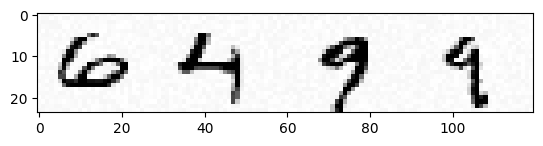

In [13]:
img, y, y_enc = trainset[0]
print('output text:', y)
print('output text encoded:', y_enc)
print('image shape:', img.shape)
print('image dtype:', img.dtype)
plt.imshow(1-img.numpy(), cmap='gray')
    

# Train the network

In [14]:
model = Transformer(vocab_size=24, 
                    nb_layers=4, 
                    d_model=128, d_ff=256, 
                    n_heads=8, d_head=64,
                    dropout=0.1, 
                    seq_len=20)

device = 'cuda'
model.to(device)
# opt = torch.optim.Adam(model.parameters(), lr=1e-3)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

nb_epochs = 15
batch_size = 32
model.train()

trainloader = torch.utils.data.DataLoader(trainset, batch_size, shuffle=True)
for e in range(nb_epochs):
    avg_loss = 0
    for x,_,y in trainloader:
        x = x.to(device)
        y = y.to(device)
        opt.zero_grad()
        loss = model.loss(x, y)
        loss.backward()
        opt.step()
        avg_loss += loss.item()
    print('epoch %d/%d: avg_loss: %.2f' % (e,nb_epochs,avg_loss/len(trainloader)))
       
torch.save( [model, opt], 'model21.pt')

Self Attention, d_model: 128 n_heads: 8 d_head: 64
Self Attention, d_model: 128 n_heads: 8 d_head: 64
Self Attention, d_model: 128 n_heads: 8 d_head: 64
Self Attention, d_model: 128 n_heads: 8 d_head: 64
Causal Self Attention, d_model: 128 n_heads: 8 d_head: 64 seq_len: 20
Causal Self Attention, d_model: 128 n_heads: 8 d_head: 64 seq_len: 20
Causal Self Attention, d_model: 128 n_heads: 8 d_head: 64 seq_len: 20
Causal Self Attention, d_model: 128 n_heads: 8 d_head: 64 seq_len: 20
Cross Attention, d_model: 128 n_heads: 8 d_head: 64
Cross Attention, d_model: 128 n_heads: 8 d_head: 64
Cross Attention, d_model: 128 n_heads: 8 d_head: 64
Cross Attention, d_model: 128 n_heads: 8 d_head: 64
epoch 0/15: avg_loss: 0.82
epoch 1/15: avg_loss: 0.27
epoch 2/15: avg_loss: 0.15
epoch 3/15: avg_loss: 0.10
epoch 4/15: avg_loss: 0.07
epoch 5/15: avg_loss: 0.06
epoch 6/15: avg_loss: 0.05
epoch 7/15: avg_loss: 0.04
epoch 8/15: avg_loss: 0.03
epoch 9/15: avg_loss: 0.03
epoch 10/15: avg_loss: 0.03
epoch 11/1

# Test the network

Trainset example 0.

6 + 4 + 9 + 9 = 1 0 + 1 8 = 2 8
6 + 4 + 9 + 9 = 1 0 + 1 8 = 2 8


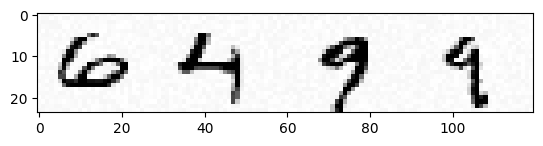

In [15]:
img, ytxt, y = trainset[0]
plt.imshow(1-img.numpy(), cmap='gray')
y_pred = model.generate(img)
print( ytxt )
print( tokenizer.decode(y_pred) )

Testset example 0.

1 + 3 + 8 + 3 = 4 + 1 1 = 1 5
1 + 8 + 8 + 3 = 9 + 1 1 = 2 0


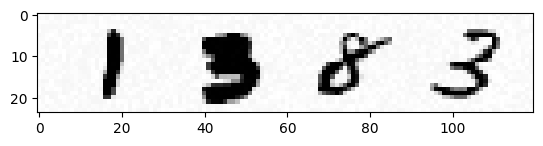

In [16]:
img, ytxt, y = testset[0]
plt.imshow(1-img.numpy(), cmap='gray')
y_pred = model.generate(img)
print( ytxt )
print( tokenizer.decode(y_pred) )

Testset example 1.

0 + 3 + 9 + 8 = 3 + 1 7 = 2 0
0 + 3 + 9 + 8 = 3 + 1 7 = 2 0


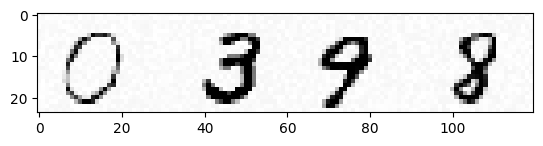

In [17]:
img, ytxt, y = testset[1]
plt.imshow(1-img.numpy(), cmap='gray')
y_pred = model.generate(img)
print( ytxt )
print( tokenizer.decode(y_pred) )

# Error rate in the test set

In [18]:
#[model, opt] = torch.load('model12.pt')

model.eval()
err = 0
for i, (img, txt_out, _) in enumerate(testset):   
    y_pred = model.generate(img)
    
    if txt_out != tokenizer.decode(y_pred):
        err += 1
print(f'error rate {err/len(testset):.2%},  ({err}/{len(testset)})')

error rate 22.34%,  (248/1110)


# Visualize attention
We add a hook to cross attention layer to capture att tensors.

In [19]:
att_ = [None] *  len(model.dec.cross_att )
for i, cross_att in enumerate(model.dec.cross_att):
    cross_att.register_forward_hook(
        lambda _, ins, outs, index=i: att_.__setitem__(index, outs[-1])
    )

ejemplo 1 test set

0 + 3 + 9 + 8 = 3 + 1 7 = 2 0
0 + 3 + 9 + 8 = 3 + 1 7 = 2 0


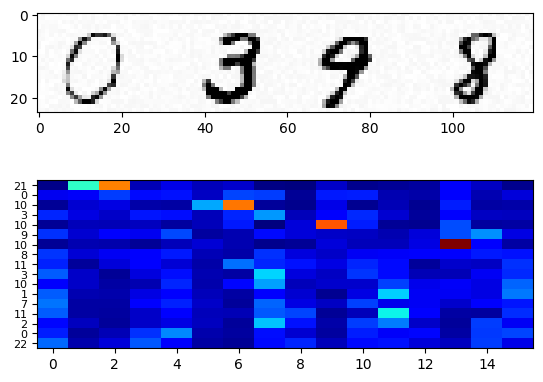

In [22]:
img, ytxt, y = testset[1]
y_pred = model.generate(img)
print( ytxt )
print( tokenizer.decode(y_pred) )


model( img.unsqueeze(0).to(device), y.unsqueeze(0).to(device)) 

plt.clf()
mean_att = torch.cat(att_).mean([0, 1])
plt.subplot(2,1,1)
plt.imshow(1-img.numpy(), cmap='gray')
plt.subplot(2,1,2)
i = y.tolist().index(22)
y = y[:i+1]
plt.imshow(mean_att[:i+1].cpu().detach().numpy(), interpolation='none', cmap='jet', aspect='auto')
ax = plt.gca()
ax.set_yticks(np.arange(len(y)), y.tolist(), fontsize=8)

ejemplo 52 test set

9 + 9 + 1 + 7 = 1 8 + 8 = 2 6
9 + 9 + 1 + 7 = 1 8 + 8 = 2 6


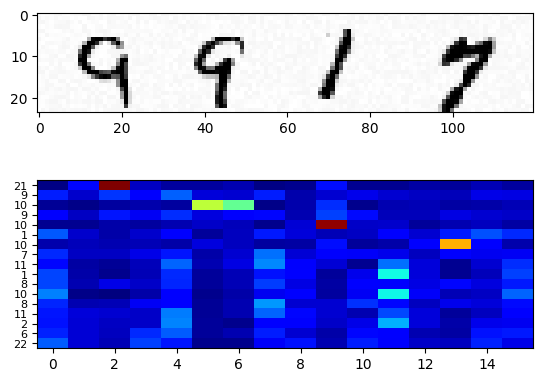

In [23]:
img, ytxt, y = testset[52]
y_pred = model.generate(img)
print( ytxt )
print( tokenizer.decode(y_pred) )


model( img.unsqueeze(0).to(device), y.unsqueeze(0).to(device)) 

plt.clf()
mean_att = torch.cat(att_).mean([0, 1])
plt.subplot(2,1,1)
plt.imshow(1-img.numpy(), cmap='gray')
plt.subplot(2,1,2)
i = y.tolist().index(22)
y = y[:i+1]
plt.imshow(mean_att[:i+1].cpu().detach().numpy(), interpolation='none', cmap='jet', aspect='auto')
ax = plt.gca()
ax.set_yticks(np.arange(len(y)), y.tolist(), fontsize=8)